In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

project_path = "./examples/elastic/VTI-elastic-Anomaly-eps-delta/data"

ox, oz = 0, 0             # Origin coordinates for x and z directions
nz, nx = 80, 180          # Grid dimensions in z and x directions
dx, dz = 10, 10           # Grid spacing in x and z directions
nt, dt = 1000,0.001       # Time steps and time interval
nabc = 50                 # Thickness of the absorbing boundary layer
f0 = 30                   # Initial frequency in Hz
free_surface = True       # Enable free surface boundary condition

# Define source positions in the model
src_z = np.array([70 for i in range(1,nx-1,5)])*dz/1000
src_x = np.array([i  for i in range(1,nx-1,5)])*dx/1000
# Define receiver positions in the model
rcv_z = np.array([10 for i in range(0,nx,1)])*dz/1000
rcv_x = np.array([j  for j in range(0,nx,1)])*dx/1000

init_model  = np.load(os.path.join(project_path,"model/init_model.npz"))
true_model  = np.load(os.path.join(project_path,"model/true_model.npz"))
init_vp     = init_model["vp"]
init_vs     = init_model["vs"]
init_rho    = init_model["rho"]
init_delta  = init_model["delta"]
init_eps    = init_model["eps"]
init_gamma  = init_model["gamma"]
true_vp     = true_model["vp"]
true_vs     = true_model["vs"]
true_rho    = true_model["rho"]
true_delta  = true_model["delta"]
true_eps    = true_model["eps"]
true_gamma  = true_model["gamma"]


In [2]:
inv_vp      = np.load(os.path.join(project_path,"inversion/iter_vp.npz"))["data"]
inv_rho     = np.load(os.path.join(project_path,"inversion/iter_rho.npz"))["data"]
inv_vs      = np.load(os.path.join(project_path,"inversion/iter_vs.npz"))["data"]
inv_eps     = np.load(os.path.join(project_path,"inversion/iter_eps.npz"))["data"]
inv_delta   = np.load(os.path.join(project_path,"inversion/iter_delta.npz"))["data"]
inv_loss= np.load(os.path.join(project_path,"inversion/iter_loss.npz"))["data"] 
inv_vp.shape,inv_vs.shape,inv_loss.shape

((500, 80, 180), (500, 80, 180), (500,))

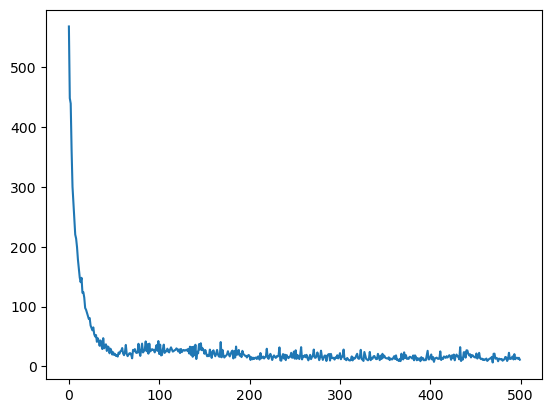

In [3]:
plt.figure()
plt.plot(inv_loss)
plt.show()

In [4]:
cmap = "bwr"
vpmin = true_vp.min()
vpmax = true_vp.max()
vsmin = true_vs.min()
vsmax = true_vs.max()
rhomin = true_rho.min()
rhomax = true_rho.max()

z = np.arange(0,nz*dz/1000,dz/1000)
x = np.arange(0,nx*dx/1000,dx/1000)
x_mesh, z_mesh = np.meshgrid(x, z)

In [9]:
def plot_vel_single_for_all(fig,ax,v,vmin=None,vmax=None,title="",MSE="",cmap = "rainbow"):
    plt.rc('font',family='Helvetica')
    x = np.arange(nx)*dx/1000
    z = np.arange(nz)*dz/1000
    x_mesh_new,z_mesh_new = np.meshgrid(x,z)
    from scipy.interpolate import griddata
    v_new = griddata((x_mesh.flatten(), z_mesh.flatten()), v.flatten(), (x_mesh_new, z_mesh_new), method='cubic')
    if vmin is not None and vmax is not None:
        plm = ax.pcolormesh(x_mesh_new, z_mesh_new, v_new,cmap=cmap,vmin=vmin,vmax=vmax,shading="nearest")
    else:
        plm = ax.pcolormesh(x_mesh_new, z_mesh_new, v_new,cmap=cmap,shading="nearest")
    ax.invert_yaxis()
    ax.tick_params(labelsize = 16)
    # if title != "":
    #     ax.set_title(title,fontsize=16)
    # if MSE != "":
    #     ax.text(5.3,0.35,MSE,fontsize=16,c="w")
    return plm

import matplotlib.transforms as mtransforms
def add_right_cax(ax, pad, width):
    axpos = ax.get_position()
    caxpos = mtransforms.Bbox.from_extents(
        axpos.x1 + pad,
        axpos.y0,
        axpos.x1 + pad + width,
        axpos.y1
    )
    cax = ax.figure.add_axes(caxpos)

    return cax

def add_bottom_cax(ax, pad, height):
    import matplotlib.transforms as mtransforms
    
    axpos = ax.get_position()
    caxpos = mtransforms.Bbox.from_extents(
        axpos.x0,
        axpos.y0 - pad - height,
        axpos.x1,
        axpos.y0 - pad
    )
    cax = ax.figure.add_axes(caxpos)
    
    return cax

def plot_vel_singleline_for_all(ax,v_true,v_init,v_inv,x_distance,title,show_xlabel=True,show_ylabel=False,show_legend=False):
    ax.plot(v_true[:,int(x_distance//dx)]/1000,  z, c='k',   linewidth=2, linestyle="-" ,label="True")
    ax.plot(v_init[:,int(x_distance//dx)]/1000,  z, c='gray',linewidth=2, linestyle="-" ,label="Init")
    ax.plot(v_inv [:,int(x_distance//dx)]/1000,  z, c='r',   linewidth=2, linestyle="--",label="Inverted")
    ax.tick_params(labelsize = 16)
    if not show_xlabel:
        ax.set_xticks([])
    # else:
    #     ax.tick_params(labelsize = 15)
        
    if not show_ylabel:
        ax.set_yticks([])
    else:
        ax.tick_params(labelsize = 12)
    ax.invert_yaxis()
    
    if show_legend:
        ax.legend(fontsize = 12)
    ax.set_title(title,fontsize=16)

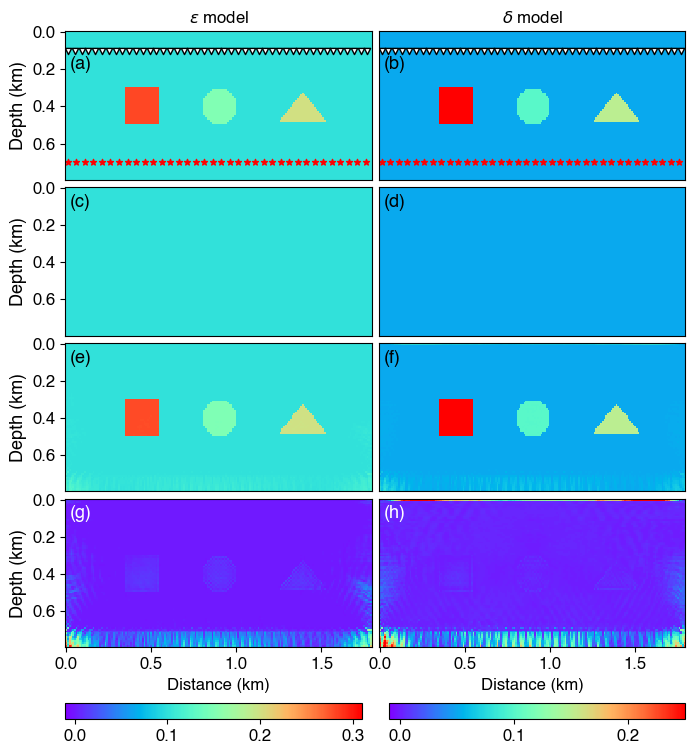

In [15]:
from matplotlib import gridspec
import matplotlib.pyplot as plt
plt.rc('font',family='Helvetica')

fig = plt.figure(figsize=(8, 8))
gs = gridspec.GridSpec(4, 4)
ax10 = fig.add_subplot(gs[0, :2])
ax11 = fig.add_subplot(gs[1, :2])
ax12 = fig.add_subplot(gs[2, :2])
ax13 = fig.add_subplot(gs[3, :2])
ax20 = fig.add_subplot(gs[0, 2:])
ax21 = fig.add_subplot(gs[1, 2:])
ax22 = fig.add_subplot(gs[2, 2:])
ax23 = fig.add_subplot(gs[3, 2:])

epsmin = -0.01
epsmax = 0.31
im1 = plot_vel_single_for_all(fig,ax10,true_eps     ,title=r"True $\epsilon$",vmin=epsmin,vmax=epsmax)
ax10.set_ylabel("Depth (km)",fontsize=13)
ax10.set_xticks([])
plot_vel_single_for_all(fig,ax11,init_eps           ,title=r"Initial $\epsilon$",vmin=epsmin,vmax=epsmax)
ax11.set_ylabel("Depth (km)",fontsize=13)
ax11.set_xticks([])
plot_vel_single_for_all(fig,ax12,inv_eps[-1]        ,title=r"Inverted $\epsilon$",vmin=epsmin,vmax=epsmax)
ax12.set_ylabel("Depth (km)",fontsize=13)
ax12.set_xticks([])
plot_vel_single_for_all(fig,ax13,np.abs(inv_eps[-1]-true_eps)*10,title=r"Difference $\times$ 10",cmap='rainbow',vmin=epsmin,vmax=epsmax)
ax13.set_ylabel("Depth (km)",fontsize=13)
ax13.set_xlabel("Distance (km)", fontsize=12)
ax10.scatter(rcv_x[1::4],rcv_z[1::4],facecolor="w",edgecolor='k',marker="v",s=20)
ax10.scatter(src_x[::],src_z[::],c="r",marker="*",s=20)

deltamin = -0.01
deltamax = 0.25
im2 = plot_vel_single_for_all(fig,ax20,true_delta     ,vmin=deltamin,vmax=deltamax)
ax20.set_xticks([])
ax20.set_yticks([])
plot_vel_single_for_all(fig,ax21,init_delta           ,vmin=deltamin,vmax=deltamax)
ax21.set_xticks([])
ax21.set_yticks([])
plot_vel_single_for_all(fig,ax22,inv_delta[-1]        ,vmin=deltamin,vmax=deltamax)
ax22.set_xticks([])
ax22.set_yticks([])
plot_vel_single_for_all(fig,ax23,np.abs(inv_delta[-1]-true_delta)*10,cmap='rainbow',vmin=deltamin,vmax=deltamax)
ax23.set_xlabel("Distance (km)", fontsize=12)
ax23.set_yticks([])
ax20.scatter(rcv_x[1::4],rcv_z[1::4],facecolor="w",edgecolor='k',marker="v",s=20)
ax20.scatter(src_x[::],src_z[::],c="r",marker="*",s=20)

# # colorbar
cax1 = add_bottom_cax(ax13,pad=0.07,height=0.02)
cbar1 = fig.colorbar(im1, cax=cax1, orientation='horizontal')
cbar1.ax.tick_params(labelsize=12)

cax2 = add_bottom_cax(ax23,pad=0.07,height=0.02)
cbar2 = fig.colorbar(im2, cax=cax2, orientation='horizontal')
cbar2.ax.tick_params(labelsize=12)

ax10.tick_params(labelsize=12)
ax11.tick_params(labelsize=12)
ax12.tick_params(labelsize=12)
ax13.tick_params(labelsize=12)
ax23.tick_params(labelsize=12)

# ax10.text(1.4,0.2,r"True $\epsilon$",fontsize=13)
# ax11.text(1.4,0.1,r"Initial $\epsilon$",fontsize=13)
# ax12.text(1.25,0.1,r"Inverted  $\epsilon$",fontsize=13)
# ax13.text(1.0,0.1,r"Difference $\times$ 10",c='w',fontsize=13)
# ax20.text(1.4,0.2,r"True $\delta$",fontsize=13)
# ax21.text(1.4,0.1,r"Initial $\delta$",fontsize=13)
# ax22.text(1.25,0.1,r"Inverted  $\delta$",fontsize=13)
# ax23.text(1.0,0.1,r"Difference $\times$ 10",c='w',fontsize=13)
ax10.set_title(r"$\epsilon$ model")
ax20.set_title(r"$\delta$ model")

ax10.text(0.02,0.2,r"(a)",fontsize=13)
ax11.text(0.02,0.1,r"(c)",fontsize=13)
ax12.text(0.02,0.1,r"(e)",fontsize=13)
ax13.text(0.02,0.1,r"(g)",c='w',fontsize=13)
ax20.text(0.02,0.2,r"(b)",fontsize=13)
ax21.text(0.02,0.1,r"(d)",fontsize=13)
ax22.text(0.02,0.1,r"(f)",fontsize=13)
ax23.text(0.02,0.1,r"(h)",c='w',fontsize=13)

plt.subplots_adjust(hspace=0.05,wspace=0.05)
plt.savefig(os.path.join(project_path,"Figure5_AnisotropicElastic_Model_Test.png"),bbox_inches="tight",dpi=300)
plt.show()

## GIF

In [ ]:
iter_eps,iter_delta,iter_gamma = inv_eps[::5],inv_delta[::5],np.zeros_like(inv_eps)[::5]

###########################################
# visualize the inversion results
###########################################
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import os

# Set up the figure for plotting
fig, ax = plt.subplots(3, 1, figsize=(6, 10))  # Increase figsize for better spacing
cax1 = ax[0].imshow(iter_eps[0]     , aspect='equal', cmap='jet_r', vmin=iter_eps.min(), vmax=iter_eps.max())
cax2 = ax[1].imshow(iter_delta[0]   , aspect='equal', cmap='jet_r', vmin=iter_delta.min(), vmax=iter_delta.max())
cax3 = ax[2].imshow(iter_gamma[0]   , aspect='equal', cmap='jet_r', vmin=iter_gamma.min(), vmax=iter_gamma.max())

# Create horizontal colorbars with adjustments
cbar1 = fig.colorbar(cax1, ax=ax[0], orientation='vertical', fraction=0.046, pad=0.1, shrink=0.8)
cbar2 = fig.colorbar(cax2, ax=ax[1], orientation='vertical', fraction=0.046, pad=0.1, shrink=0.8)
cbar3 = fig.colorbar(cax3, ax=ax[2], orientation='vertical', fraction=0.046, pad=0.1, shrink=0.8)

# Set titles for each subplot
ax[0].set_title(r'$\epsilon$', fontsize=12)
ax[1].set_title(r'$\delta$', fontsize=12)
ax[2].set_title(r'$\gamma$', fontsize=12)

# Adjust layout to ensure centering
# plt.subplots_adjust(top=0.85, bottom=0.35, left=0.1, right=0.9)

# Initialization function
def init():
    cax1.set_array(iter_eps[0])
    cax2.set_array(iter_delta[0])
    cax3.set_array(iter_gamma[0])
    return cax1, cax2, cax3

# Animation function
def animate(i):
    cax1.set_array(iter_eps[i])
    cax2.set_array(iter_delta[i])
    cax3.set_array(iter_gamma[i])
    return cax1, cax2, cax3

# Create the animation
ani = animation.FuncAnimation(fig, animate, init_func=init, frames=len(iter_eps), interval=200, blit=True)

# Save the animation as a GIF file
ani.save(os.path.join(project_path, "inversion/inversion_process.gif"), writer='pillow', fps=10)

# Display the animation using HTML
plt.close(fig)  # Prevents static display of the last frame
HTML(ani.to_jshtml())